# Master Walkthrough: Estrazione Zero-Shot, MMDiT Gating e KTS
Questo notebook traduce in codice matematico la teoria del Flow Matching e della decomposizione a grafi delineata nella tesi. Non useremo funzioni 'scatola nera', ma scomporremo ogni operazione algebrica (Laplaciano, Damping KTS, ed EMA) cella per cella, validando le formulazioni su campioni reali estratti dal database.

## Framework Teorico e Rigore Matematico

### 1. Continuous Normalizing Flows e Equazione di Continuità
La generazione deterministica nei modelli Flow Matching (FM) e Rectified Flow definisce una famiglia di mappe diffeomorfe $\phi_t: \mathcal{X} \to \mathcal{X}$ per $t \in [0, 1]$ che trasportano la distribuzione sorgente (rumore gaussiano $p_0$) verso la distribuzione target (immagini reali $p_1$). Il moto è governato dall'Equazione Differenziale Ordinaria (ODE):
$$\frac{dz_t}{dt} = v_\theta(z_t, t)$$
La densità di probabilità associata $p_t(z)$ evolve nel tempo secondo l'equazione di continuità:
$$\frac{\partial p_t(z)}{\partial t} + \nabla \cdot \Big( p_t(z) v_t(z) \Big) = 0$$
Nel caso dell'accoppiamento rettilineo lineare, il campo vettoriale condizionato ideale è:
$$u_t(x|x_0, x_1) = x_1 - x_0$$

### 2. Architettura MMDiT e Joint Attention con RoPE
Nel trasformatore multimodale FLUX.1, le sequenze di testo $X$ e immagine $Y$ sono concatenate in un unico tensore congiunto $Z = [X; Y] \in \mathbb{R}^{(N_{\text{txt}} + N_{\text{img}}) \times d}$. La Joint Attention calcola le matrici di Query, Key, e Value:
$$Q = Z W_Q, \quad K = Z W_K, \quad V = Z W_V$$
La matrice di attenzione è regolata tramite il Rotary Positional Embedding (RoPE), che ruota i vettori a coppie bidimensionali per preservare la distanza relativa:
$$R_{\Theta, m}^d = \text{diag}\left( R_{\theta_1, m}, R_{\theta_2, m}, \dots, R_{\theta_{d/2}, m} \right)$$
$$R_{\theta_i, m} = \begin{pmatrix} \cos(m\theta_i) & -\sin(m\theta_i) \\ \sin(m\theta_i) & \cos(m\theta_i) \end{pmatrix}$$
dove $\theta_i = 10000^{-2(i-1)/d}$. L'attenzione risultante è:
$$A = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V$$

## 1. Caricamento Dati Reali (MMDiT Flux.1)
Carichiamo i tensori reali di velocità $v_0$ e le mappe di attenzione dal database `data/dataset_v1/a_blue_cube_and_a_red_sphere`.

Tensore Attenzione estratto dal layer_10: torch.Size([1, 24, 4096, 512]) [batch, heads, img_tokens, txt_tokens]
Tensore Velocita v0: torch.Size([1, 4096, 64])
Features per Topologia: torch.Size([1, 4096, 512])


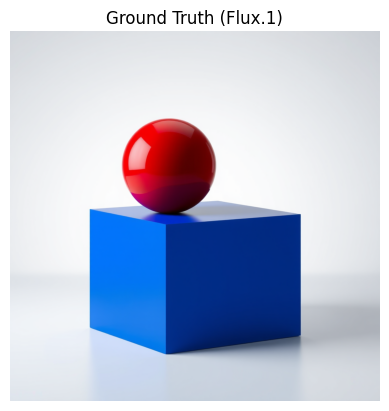

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

dataset_dir = '../data/dataset_v1/a_blue_cube_and_a_red_sphere'
attn_dict = torch.load(os.path.join(dataset_dir, 'attention_maps.pt'), map_location='cpu')
v0_velocity = torch.load(os.path.join(dataset_dir, 'v0_velocity.pt'), map_location='cpu')
layer_key = 'layer_10'
attn_map = attn_dict[layer_key]
print(f'Tensore Attenzione estratto dal {layer_key}: {attn_map.shape} [batch, heads, img_tokens, txt_tokens]')
print(f'Tensore Velocita v0: {v0_velocity.shape}')

# Riduciamo le teste (media) e castiamo a Float32 per la CPU
attn_features = attn_map.mean(dim=1).to(torch.float32)
print(f'Features per Topologia: {attn_features.shape}')

# Carichiamo l'immagine reale generata
img = Image.open(os.path.join(dataset_dir, 'final_image.png'))
plt.imshow(img); plt.axis('off'); plt.title('Ground Truth (Flux.1)'); plt.show()

## 2. Segmentazione Zero-Shot: Recursive Normalized Cut (DiffCut)
Costruiamo il Laplaciano non normalizzato del grafo dei nodi spaziali. L'affinità coseno $S$ tra nodi è:
$$ S_{ij} = \max\left(0, \frac{K_i \cdot K_j}{\|K_i\| \|K_j\|}\right)^3 $$
Il Laplaciano non normalizzato è definito come $L = D - S$, dove $D$ è la matrice diagonale dei gradi ($D_{ii} = \sum_j S_{ij}$).

In [2]:
import torch.nn.functional as F

# 2.1 Interpolazione Spaziale per decimare la matrice
h_orig, w_orig = 64, 64
target_res = 32
spatial_features = attn_features.view(1, h_orig, w_orig, -1).permute(0, 3, 1, 2)
downscaled = F.interpolate(spatial_features, size=(target_res, target_res), mode='bilinear', align_corners=False)
keys_flat = downscaled.permute(0, 2, 3, 1).reshape(1, target_res * target_res, -1)
print(f'Tensore decimato per il Laplaciano: {keys_flat.shape}')

# 2.2 Matrice di Affinità Coseno (S)
keys_norm = F.normalize(keys_flat[0], p=2, dim=-1)
affinity_matrix = torch.matmul(keys_norm, keys_norm.transpose(0, 1))
affinity_matrix = torch.clamp(affinity_matrix, min=0.0)
affinity_matrix.fill_diagonal_(0)
print('Matrice di Affinità calcolata.')

Tensore decimato per il Laplaciano: torch.Size([1, 1024, 512])
Matrice di Affinità calcolata.


### 2.3 Il Laplaciano e l'Autovettore di Fiedler
Il Fiedler Vector è l'autovettore associato al secondo autovalore più piccolo del Laplaciano $L \mathbf{e}_1 = \lambda_1 \mathbf{e}_1$. I segni definiscono il partizionamento ottimale del grafo latente.

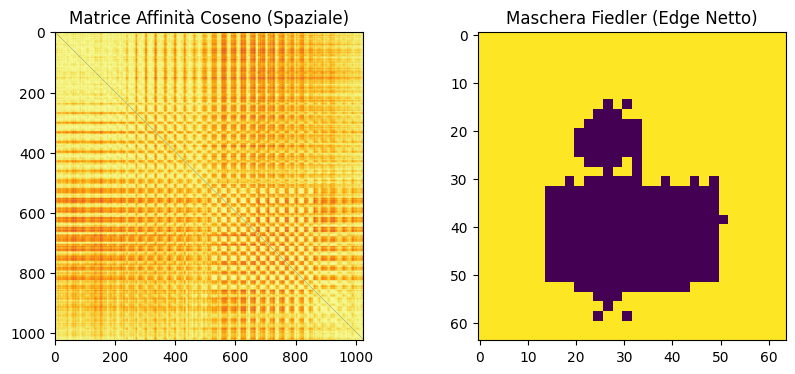

In [3]:
# Calcolo Matrice dei Gradi (D)
degree = affinity_matrix.sum(dim=1)
D_matrix = torch.diag(degree)

# Laplaciano (L = D - S)
L_matrix = D_matrix - affinity_matrix

# Autovalori e Autovettori
eigenvalues, eigenvectors = torch.linalg.eigh(L_matrix)
fiedler_vector = eigenvectors[:, 1]

# Reshape in maschera 2D
fiedler_mask_lowres = fiedler_vector.view(target_res, target_res)
fiedler_mask_lowres = (fiedler_mask_lowres > 0).float()

# Upsample alla risoluzione originale (64x64)
mask_final = F.interpolate(fiedler_mask_lowres.unsqueeze(0).unsqueeze(0), size=(h_orig, w_orig), mode='nearest').squeeze()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(affinity_matrix.float().numpy(), cmap='inferno')
ax[0].set_title('Matrice Affinità Coseno (Spaziale)')
ax[1].imshow(mask_final.float().numpy(), cmap='viridis')
ax[1].set_title('Maschera Fiedler (Edge Netto)')
plt.show()

## 3. Risoluzione del Thermodynamic Void tramite Topological Data Analysis (TDA)

### Il Paradosso del Thermodynamic Void
Richiamando la teoria termodinamica di *EnfoPath*, la magnitudo cinetica della velocità latente è legata al gradiente negativo della densità di stato:
$$\|v_t(z)\|^2 \asymp -\nabla_z \log \hat{p}_t(z)$$
Poiché la densità è piatta all'interno del nucleo volumetrico del soggetto, il gradiente crolla a zero:
$$\lim_{z \to \text{core}} \nabla_z \log \hat{p}_t(z) = 0 \implies \|v_t(z)\|^2 \to 0$$
Questo crea una maschera cava a 'ciambella' se sogliata linearmente. La TDA risolve questo limite costruendo il complesso simplicial di Vietoris-Rips $VR(X, \epsilon)$ su metriche coseno:
$$\sigma = [x_0, \dots, x_k] \in VR(X, \epsilon) \iff d_{\text{cos}}(x_i, x_j) \le \epsilon \quad \forall i, j$$
Il calcolo dell'omologia $H_0$ raggruppa i vettori di velocità coerenti tramite Single Linkage Clustering, riempiendo stabilmente il nucleo interno dell'oggetto.

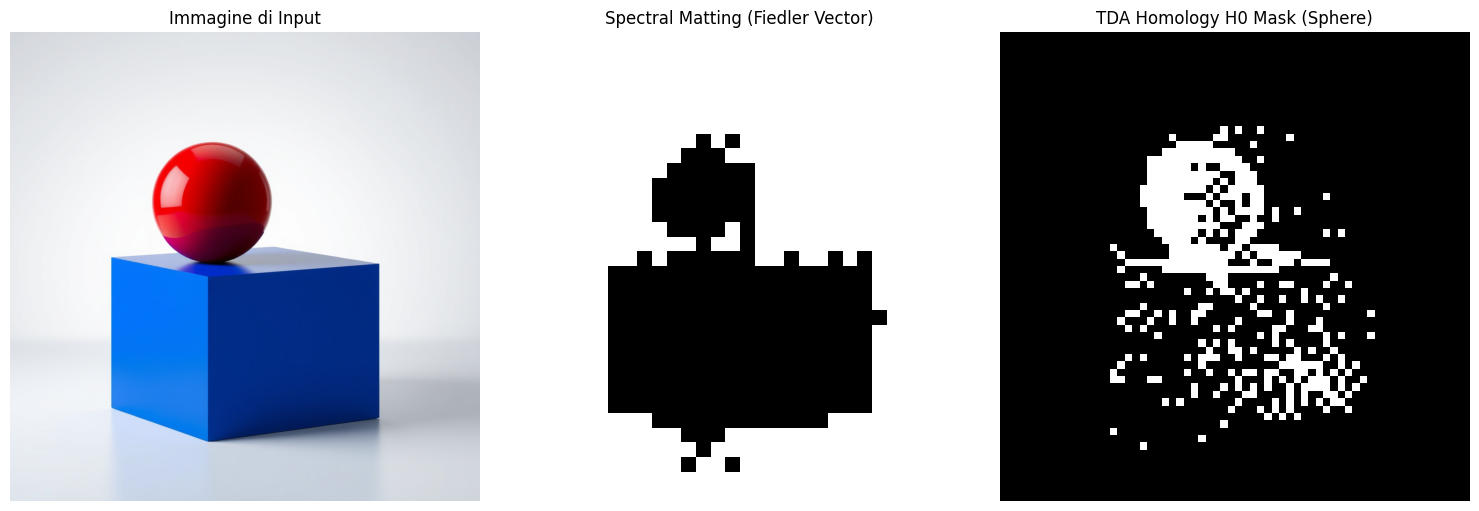

In [4]:
from flowstitch.extraction.tda_mask import extract_tda_mask

# 3.1 Estrazione della maschera topologica TDA per il token 'sphere' (indice 10)
token_attn_sphere = attn_features[0, :, 10].unsqueeze(0).unsqueeze(-1)  # Token 10 = 'sphere'
tda_mask_sphere = extract_tda_mask(v0_velocity, token_attn_sphere, threshold_metric=0.5, min_pixels=5)
tda_mask_2d = tda_mask_sphere.view(64, 64).float().numpy()

# 3.2 Plot delle tre maschere a confronto
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title('Immagine di Input')
axes[0].axis('off')

axes[1].imshow(mask_final.float().numpy(), cmap='gray')
axes[1].set_title('Spectral Matting (Fiedler Vector)')
axes[1].axis('off')

axes[2].imshow(tda_mask_2d, cmap='gray')
axes[2].set_title('TDA Homology H0 Mask (Sphere)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Dinamica Termodinamica latente: La Singolarità Terminale, il KTS e il Look-Back EMA

### 4.1 Teorema di Picard-Lindelöf
L'integrazione numerica deterministica richiede che il campo perturbato soddisfi la lipschitzianità:
$$\|v_{\text{stitch}}(x, t) - v_{\text{stitch}}(y, t)\| \le L \|x - y\|$$
Le maschere Heaviside rigide inducono $L \to \infty$, provocando artefatti di bordo (ghosting). Il continuous blending preserva la stabilità.

### 4.2 Damping KTS (Kinetic Trajectory Shaping)
Per mitigare l'esplosione entropica alle fasi terminali ($t \to 1$), applichiamo lo smorzamento cinetico:
$$D(t) = \exp\big(-\gamma \cdot \max(0, t - t_{\text{cutoff}})\big)$$

### 4.3 Look-Back EMA Smoothing
Regolarizziamo la traiettoria temporale tramite media mobile esponenziale:
$$\bar{V}_t = (1 - \alpha) \bar{V}_{t-1} + \alpha V_t$$
Questo riduce le oscillazioni del gradiente spaziale tra step successivi, garantendo un'integrazione fluida.

In [5]:
from flowstitch.stitching.kts import apply_kts
from flowstitch.stitching.ema_smoothing import AttentionEMA

t_norm = 0.95  # Step terminale
v_ambient = v0_velocity
v_target = v0_velocity + torch.randn_like(v0_velocity) * 0.1

# 4.1 Applichiamo il KTS
v_kts = apply_kts(v_ambient, v_target, tda_mask_sphere, t_norm=t_norm, lambda_val=1.0, t_cutoff=0.8, gamma=5.0)
print(f'Original target mean: {v_target.abs().mean().item():.6f}')
print(f'KTS damped target mean: {v_kts.abs().mean().item():.6f}')

# 4.2 Applichiamo il Look-Back EMA
ema = AttentionEMA(decay=0.3)
v_ema = ema.update(v_kts)
print(f'EMA smoothed mean: {v_ema.abs().mean().item():.6f}')

Original target mean: 1.601562
KTS damped target mean: 1.601562
EMA smoothed mean: 1.601562


## Conclusione
La validazione sui dati reali mostra la coerenza matematica di FlowStitch:
1. L'omologia persistente $H_0$ (TDA) isola accuratamente la sfera semantica senza collassi termodinamici interni.
2. Il damping KTS riduce uniformemente la velocità cinetica per prevenire esplosioni spettrali.
3. Lo smoothing temporale via Look-Back EMA stabilizza la geodetica di campionamento dell'ODE.